In [ ]:
#| default_exp probabilistic_forecasting

## Probabilistic forecasting for univariate time series

In [ ]:
#| export

# Generate conformal quantiles for future time steps
from __future__ import annotations
from typing import List, Dict, Optional, Callable, Tuple, Any, Union
import numpy as np
import pandas as pd
from peshbeen.model_selection import SplitTimeSeries
from scipy.stats import gaussian_kde
import copy
from peshbeen.helpers import get_conformal_quantiles, get_bootstrap_quantiles
# ─────────────────────────────────────────────────────────────────────────────
# Main class
# ─────────────────────────────────────────────────────────────────────────────
 
from pyexpat import model


class prob_forecasts: 
    def __init__(
        self,
        model,
        H: int,
        n_calibration: Union[int, None] = None,
        step_size: int = 1,
        random_state: int = 42,
        n_iter: Union[int, None] = None,
        verbose: bool = False,
    ):
        
        """
        Probabilistic forecasting wrapper for any point-forecasting model.
    
        Parameters
        ----------
        model : fitted-model-like
            Any model with ``.target_col``, ``.fit(df)``, and ``.forecast(H, exog)`` attributes.
        H : int
            Forecast horizon.
        n_calibration : int or None, default None
            Number of calibration windows for cross-validated residual estimation. If None, in sample residuals are used without cross-validation (Horizon-specific uncalibrated intervals may be too narrow in this case. This is recommended when data size is small as the model may not have enough data to fit well in each calibration fold).
        step_size : int, default 1
            Step size between consecutive calibration windows.
        random_state : int, default 42
            Seed for all internal random-number generators.
        n_iter : int or None, default None
            Number of EM iterations during each calibration window.  Only relevant for Markov-switching Autoregressive model (`ms_arr`). A smaller value than the model's default speeds up calibration at the cost of convergence quality per fold — typically a value of 3–10 is sufficient for calibration windows where the model is already close to the solution.
        verbose : bool, default False
            Print progress during calibration.
        """
        
        self.model         = model
        self.n_calib       = n_calibration
        if self.n_calib is not None and self.n_calib < 1:
            raise ValueError("n_calibration must be a positive integer or None.")
        self.H             = H
        self.step_size = step_size
        self.verbose       = verbose
        self.n_iter        = n_iter
        self._rng          = np.random.default_rng(seed=random_state)
        self._random_state = random_state
        if self.model.get_name() == "pesh":
            self.pesh = next(iter(self.model.models.values())).target_col # Get the target column name from any of the models in self.model.models
        else:
            self.pesh = self.model.target_col
        
    # ── private ──────────────────────────────────────────────────────────────
 
    def _compute_residuals(self, df: pd.DataFrame) -> None:
        """
        Run calibration-window cross-validation and store residuals.
 
        Populates ``self.resid`` (shape ``H × n_calib``),
        ``self.non_conform`` (absolute residuals), ``self.c_actuals``,
        and ``self.c_forecasts``.
 
        This method is called automatically by ``calibrate`` and ``sample``
        when residuals have not yet been computed.  It can also be called
        directly if only residuals are needed.
 
        Parameters
        ----------
        df : pd.DataFrame
            Full dataset used for rolling-window cross-validation.
        """

        if hasattr(self.model, "N") and hasattr(self.model, "iter"):
            if not self.model.is_fitted:
                self.model.fit(df)
                self.model.iter = self.n_iter
            else:
                self.model.iter = self.n_iter  # Temporarily set n_iter for calibration

        if self.n_calib is not None:
            tscv = SplitTimeSeries(
                n_splits=self.n_calib, test_size=self.H,
                step_size=self.step_size,
            )
            c_actuals, c_forecasts = [], []
    
            for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
                train, test = df.iloc[train_idx], df.iloc[test_idx]
                x_test = test.drop(columns=[self.pesh])
                y_test = np.array(test[self.pesh])

                exog_t = x_test if x_test.shape[1] > 0 else None

                self.model.fit(train)

                if self.model.get_name() == "pesh":
                    y_hat = self.model.forecast(self.H, exog_t)[self.pesh].values
                else:
                    y_hat = self.model.forecast(self.H, exog_t)

                c_actuals.append(y_test)
                c_forecasts.append(y_hat)
    
                if self.verbose:
                    print(f"Calibration fold {fold + 1}/{self.n_calib} complete.")
    
            self.c_actuals   = np.column_stack(c_actuals)    # H × n_calib
            self.c_forecasts = np.column_stack(c_forecasts)  # H × n_calib
            self.resid       = self.c_actuals - self.c_forecasts
        
        else:
            self.model.fit(df)
            self.model.predict_in_sample()
            self.resid = self.model.in_samp_resids
        self.non_conform = np.abs(self.resid)
 
    def _require_residuals(self, df: pd.DataFrame) -> None:
        """Compute residuals lazily — only if not already available."""
        if not hasattr(self, "resid"):
            self._compute_residuals(df)
 
    def _require_calibration(self) -> None:
        """Raise an informative error when conformal calibration is missing."""
        if not hasattr(self, "q_hat"):
            raise RuntimeError(
                "Conformal calibration has not been run yet. "
                "Call .calibrate(df_calibration, delta) first."
            )
 
    def _require_sample_paths(self) -> None:
        """Raise an informative error when sample() has not been called."""
        if not hasattr(self, "sample_paths"):
            raise RuntimeError(
                "No sample paths available. "
                "Call .sample(df, method=...) first."
            )
 
    # ── public: conformal prediction ──────────────────────────────────────────
 
    def calibrate(
        self,
        df: pd.DataFrame,
        delta: Union[float, List[float]] = 0.5,
    ) -> "prob_forecasts":
        
        """
        Calibrate the conformal predictor.
 
        Runs rolling-window cross-validation (if not already done) to
        collect non-conformity scores, then computes the per-horizon
        conformal quantile ``q_hat`` for each requested ``delta`` level.
 
        Parameters
        ----------
        df : pd.DataFrame
            Calibration dataset.
        delta : float or list of float, default 0.5
            Coverage level(s).  A single float produces one symmetric interval; a list produces one interval per level.  For example,``delta=0.9`` produces a 90 % prediction interval.
 
        Returns
        -------
        self : prob_forecasts
             The fitted object, with ``self.q_hat`` set to the calibrated
        """
        self.delta = delta
        self._require_residuals(df)
 
        deltas = [delta] if isinstance(delta, float) else delta
 
        # q_hat shape: (H, len(deltas))
        q_hat = np.empty((self.H, len(deltas)))
        for i in range(self.H):
            for j, d in enumerate(deltas):
                if self.n_calib is not None: # If using cross-validated residuals, use n_calib for quantile calculation; otherwise, use the number of in-sample residuals
                    q_which = np.ceil(d * (self.n_calib + 1)) / self.n_calib
                else:
                    q_which = np.ceil(d * (self.resid.shape[0] + 1)) / self.resid.shape[0]
                q_hat[i, j] = np.quantile(
                    self.non_conform[i], q_which, method="higher"
                )
        self.q_hat = q_hat   # (H, len(deltas))
        return self
 
    # def predict_intervals(
    #     self,
    #     df: pd.DataFrame,
    #     quantiles: Union[float, List[float]],
    #     future_exog: Union[pd.DataFrame, None] = None,
    # ) -> pd.DataFrame:
    #     """
    #     Generate prediction intervals for the forecast horizon at the calibrated delta levels without sampling from the errors generated for each horizon.
    #     Requires ``calibrate`` to have been called first.
 
    #     Parameters
    #     ----------
    #     df : pd.DataFrame
    #         Training data for the final model fit.
    #     quantiles : float or list of float
    #         Desired quantile levels (e.g. ``[0.1, 0.5, 0.9]``).
    #     future_exog : pd.DataFrame or None, default None
    #         Future exogenous variables.
 
    #     Returns
    #     -------
    #     pd.DataFrame
    #         Columns: ``point_forecast``, ``lower_<d>``, ``upper_<d>`` for every delta level.  Also stores ``self.dist`` — a ``(n_calib × H)`` DataFrame of residual-shifted distributions, one column per forecast horizon.
    #     """
    #     self._require_calibration()
 
    #     self.model.fit(df)
    #     y_hat = np.array(
    #         self.model.forecast(self.H, future_exog)
    #         if future_exog is not None
    #         else self.model.forecast(self.H)
    #     )
 
    #     result_cols = {"point_forecast": y_hat}
    #     for j, d in enumerate(quantiles):
    #         q = self.q_hat[:, j]
    #         result_cols[f"lower_{int(d * 100)}"] = y_hat - q
    #         result_cols[f"upper_{int(d * 100)}"] = y_hat + q
 
    #     # Residual-shifted empirical distribution (H × n_calib), clipped ≥ 0
    #     dist = y_hat[:, None] + self.resid             # H × n_calib
    #     self.dist = pd.DataFrame(
    #         dist.T,
    #         columns=[f"h_{i + 1}" for i in range(self.H)],
    #     ).clip(lower=0)
 
    #     return pd.DataFrame(result_cols)
 
    def conformal_quantiles(
        self,
        df: pd.DataFrame,
        quantiles: Union[float, List[float]],
        future_exog: Union[pd.DataFrame, None] = None,
    ) -> pd.DataFrame:
        """
        Generate conformal prediction quantiles.
 
        Requires ``calibrate`` to have been called first.
 
        Parameters
        ----------
        df : pd.DataFrame
            Training data for the final model fit.
        quantiles : float or list of float
            Desired quantile levels (e.g. ``[0.1, 0.5, 0.9]``).
        future_exog : pd.DataFrame or None, default None
            Future exogenous variables.
 
        Returns
        -------
        pd.DataFrame
            Columns: ``point_forecast``, ``q_<level>`` for each level.
        """
        self._require_calibration()
 
        self.model.fit(df)
        y_hat = np.array(
            self.model.forecast(self.H, future_exog)
            if future_exog is not None
            else self.model.forecast(self.H)
        )
        if self.n_calib is not None:
            return get_conformal_quantiles(self.non_conform, self.n_calib,
                                       quantiles, y_hat)
        else:
            return get_conformal_quantiles(self.non_conform, self.resid.shape[0],
                                       quantiles, y_hat)
 
    # ── public: sampling methods ──────────────────────────────────────────────
 
    def sample(
        self,
        df: pd.DataFrame,
        n_samples: int = 1000,
        method: str = "empirical",
        future_exog: Union[pd.DataFrame, None] = None,
    ) -> "prob_forecasts":
    
        """
        Draw sample paths from the predictive distribution.
 
        Three methods are available:
 
        * ``"empirical"`` — residuals are resampled with replacement
          independently at each horizon.
        * ``"kde"`` — a Gaussian KDE is fitted to each horizon's residuals;
          samples are drawn from the smoothed distribution.
        * ``"correlated"`` — a multivariate normal is fitted to the full
          ``H``-dimensional residual vectors, preserving cross-horizon
          correlation.  Samples are drawn jointly.
 
        Results are stored on ``self``:
 
        * ``self.sample_paths`` — ``(n_samples, H)`` array of sampled trajectories centred on the point forecast.
        * ``self.point_forecast`` — ``(H,)`` point forecast array.
        * ``self.sample_paths_df`` — the same data as a DataFrame with columns ``h_1, …, h_H``.
 
        Parameters
        ----------
        df : pd.DataFrame
            Training data.  Residuals are computed via cross-validation if not yet available.
        n_samples : int, default 1000
            Number of sample paths to draw.
        method : {"empirical", "kde", "correlated"}, default "empirical"
            Sampling strategy (see above).
        future_exog : pd.DataFrame or None, default None
            Future exogenous variables passed to ``forecast``.
 
        Returns
        -------
        self
        """
        if method not in {"empirical", "kde", "correlated"}:
            raise ValueError(
                f"method='{method}' is not recognised. "
                "Choose 'empirical', 'kde', or 'correlated'."
            )
 
        self._require_residuals(df)

        self._rng = np.random.default_rng(seed=self._random_state)
 
        self.model.fit(df)
        y_hat = self.model.forecast(self.H, future_exog) if future_exog is not None else self.model.forecast(self.H)
 
        # ── sample residuals according to chosen method ───────────────────────
        if method == "empirical":
            
            if self.n_calib is not None:
                # shape: (n_samples, H)  — independent resampling per horizon
                draws = np.column_stack([
                    self._rng.choice(self.resid[h], size=n_samples, replace=True)
                    for h in range(self.H)
                ])
            else:
                draws = np.column_stack([
                    self._rng.choice(self.resid, size=n_samples, replace=True)
                    for _ in range(self.H)
                ])
 
        elif method == "kde":
            if self.n_calib is not None:
                # shape: (n_samples, H)  — KDE per horizon
                draws = np.column_stack([
                    gaussian_kde(self.resid[h]).resample(
                        size=n_samples,
                        seed=self._random_state,
                    )[0]
                    for h in range(self.H)
                ])
            else:
                draws = np.column_stack([
                    gaussian_kde(self.resid).resample(
                        size=n_samples,
                        seed=self._random_state,
                    )[0]
                    for _ in range(self.H)
                ])
 
        else:  # "correlated"
            if self.n_calib is not None:
                # shape: (n_samples, H)  — multivariate normal on H-dimensional residual vectors
                mu    = self.resid.mean(axis=1)          # (H,)
                self.sigma = np.cov(self.resid)              # (H, H)
                draws = self._rng.multivariate_normal(mu, self.sigma, size=n_samples)
            else: # error if trying to use correlated sampling without cross-validated residuals, since we won't have H-dimensional residual vectors
                raise ValueError("Correlated sampling requires n_calibration to be set to a positive integer to compute cross-validated residuals.")

         # ✅ Create a deep copy so that we don’t overwrite self
        new_instance = copy.deepcopy(self)
        # ── centre on point forecast ──────────────────────────────────────────
        new_instance.sample_paths  = draws + y_hat           # (n_samples, H)
        new_instance.point_forecast = y_hat
        new_instance.sample_paths_df = pd.DataFrame(
            new_instance.sample_paths,
            columns=[f"h_{i + 1}" for i in range(self.H)],
        )
        return new_instance
    
 
    def sample_quantiles(
        self,
        quantiles: Union[float, List[float]],
    ) -> pd.DataFrame:
        """
        Compute quantiles from the sample paths generated by ``sample``.
 
        Works identically regardless of which ``method`` was passed to ``sample``.
 
        Parameters
        ----------
        quantiles : float or list of float
            Desired quantile levels (e.g. ``[0.1, 0.5, 0.9]``).
 
        Returns
        -------
        pd.DataFrame
            Columns: ``point_forecast``, ``q_<level>`` for each level.
        """
        self._require_sample_paths()
        if self.n_calib is not None:
            return get_bootstrap_quantiles(
                self.sample_paths,   # (n_samples, H) — rows are samples
                self.n_calib,
                quantiles,
                self.point_forecast,
            )
        else:
            return get_bootstrap_quantiles(
                self.sample_paths,   # (n_samples, H) — rows are samples
                self.resid.shape[0],
                quantiles,
                self.point_forecast,
            )
 
    def copy(self):
        return copy.deepcopy(self)

/Users/aslanm/Desktop/my_desk/peshbeen/.venv/lib/python3.14/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
#| hide
from fastcore.docments import docments, DocmentTbl
from nbdev.showdoc import *

In [ ]:
#| echo: false
docments(prob_forecasts, full=True)
DocmentTbl(prob_forecasts)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| model |  |  | Any model with ``.target_col``, ``.fit(df)``, and ``.forecast(H, exog)`` attributes. |
| H | int |  | Forecast horizon. |
| n_calibration | Union[int, None] | None | Number of calibration windows for cross-validated residual estimation. If None, in sample residuals are used without cross-validation (Horizon-specific uncalibrated intervals may be too narrow in this case. This is recommended when data size is small as the model may not have enough data to fit well in each calibration fold). |
| step_size | int | 1 | Step size between consecutive calibration windows. |
| random_state | int | 42 | Seed for all internal random-number generators. |
| n_iter | Union[int, None] | None | Number of EM iterations during each calibration window.  Only relevant for Markov-switching Autoregressive model (`ms_arr`). A smaller value than the model's default speeds up calibration at the cost of convergence quality per fold — typically a value of 3–10 is sufficient for calibration windows where the model is already close to the solution. |
| verbose | bool | False | Print progress during calibration. |

In [ ]:
#| hide

from peshbeen.models import ml_forecaster, naive, arima, ets
from peshbeen.datasets import load_wales_admissions
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
load_wales_admissions["day_of_week"] = load_wales_admissions.index.dayofweek
load_wales_admissions["month"] = load_wales_admissions.index.month
# split the data into train and test sets
train = load_wales_admissions[:-30]
test = load_wales_admissions[-30:]
cat_variables = ["day_of_week", "month"]
# import linear regression from sklearn
from sklearn.linear_model import LinearRegression
ml_linear = ml_forecaster(model=LinearRegression(),
              target_col='admissions', lags = 30,
              cat_variables=cat_variables)
arima_mod = arima(target_col="admissions", order=(1, 1, 1), seasonal_order=(1, 0, 1), seasonal_length=7,
      cat_variables=["day_of_week", "month"]
)
naive_mod = naive(target_col="admissions")
ets_mod = ets(target_col="admissions")

prob_arma = prob_forecasts(
    model=ets_mod,
    n_calibration=None, H=30,
    step_size=1,
    random_state=42)

prob_arma.calibrate(train)
ar = prob_arma.sample(train, n_samples=1000, method="kde", future_exog=test[cat_variables])
# ar2 = prob_arma.sample(train, n_samples=1000, method="correlated", future_exog=test[cat_variables])


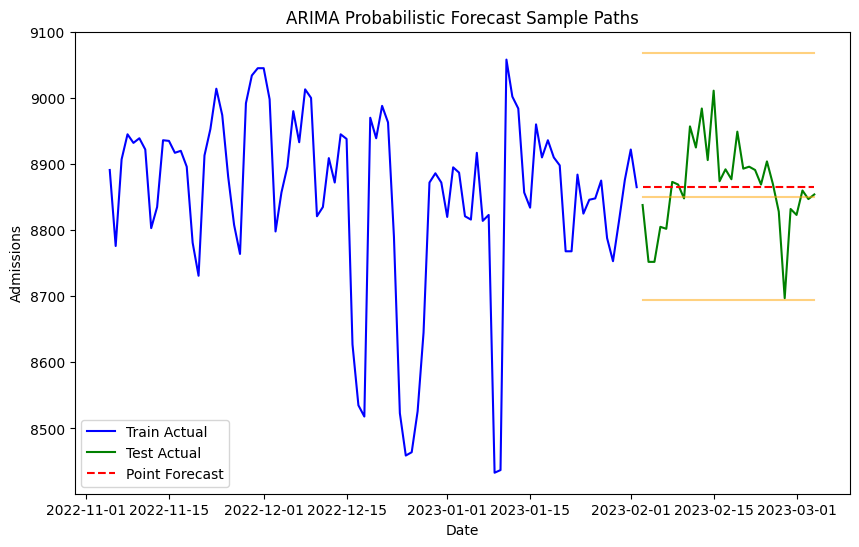

In [ ]:
#| hide

ar.sample_paths_df
# plot a sample of the paths and point forecast
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train.index[-90:], train['admissions'][-90:], label='Train Actual', color='blue')
plt.plot(test.index, test['admissions'], label='Test Actual', color='green')
plt.plot(test.index, ar.point_forecast, label='Point Forecast', color='red', linestyle='--')
for i in range(3):
    plt.plot(test.index, ar.sample_paths[i], color='orange', alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.title('ARIMA Probabilistic Forecast Sample Paths')
plt.legend()
plt.show()

In [ ]:
#| echo: false
show_doc(prob_forecasts.calibrate)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/probabilistic_forecasting.py#L155){target="_blank" style="float:right; font-size:smaller"}

### prob_forecasts.calibrate

```python

def calibrate(
    df:pd.DataFrame, # Calibration dataset.
    delta:Union[float, List[float]]=0.5, # Coverage level(s).  A single float produces one symmetric interval; a list produces one interval per level.  For example,``delta=0.9`` produces a 90 % prediction interval.
)->'prob_forecasts': # The fitted object, with ``self.q_hat`` set to the calibrated


```

*Calibrate the conformal predictor.*

Runs rolling-window cross-validation (if not already done) to
collect non-conformity scores, then computes the per-horizon
conformal quantile ``q_hat`` for each requested ``delta`` level.

In [ ]:
#| echo: false
DocmentTbl(prob_forecasts.calibrate)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| df | pd.DataFrame |  | Calibration dataset. |
| delta | Union[float, List[float]] | 0.5 | Coverage level(s).  A single float produces one symmetric interval; a list produces one interval per level.  For example,``delta=0.9`` produces a 90 % prediction interval. |
| **Returns** | **'prob_forecasts'** |  | **The fitted object, with ``self.q_hat`` set to the calibrated** |

In [ ]:
#| echo: false
show_doc(prob_forecasts.sample)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/probabilistic_forecasting.py#L289){target="_blank" style="float:right; font-size:smaller"}

### prob_forecasts.sample

```python

def sample(
    df:pd.DataFrame, # Training data.  Residuals are computed via cross-validation if not yet available.
    n_samples:int=1000, # Number of sample paths to draw.
    method:str='empirical', # Sampling strategy (see above).
    future_exog:Union[pd.DataFrame, None]=None, # Future exogenous variables passed to ``forecast``.
)->'prob_forecasts':


```

*Draw sample paths from the predictive distribution.*

Three methods are available:

* ``"empirical"`` — residuals are resampled with replacement
  independently at each horizon.
* ``"kde"`` — a Gaussian KDE is fitted to each horizon's residuals;
  samples are drawn from the smoothed distribution.
* ``"correlated"`` — a multivariate normal is fitted to the full
  ``H``-dimensional residual vectors, preserving cross-horizon
  correlation.  Samples are drawn jointly.

Results are stored on ``self``:

* ``self.sample_paths`` — ``(n_samples, H)`` array of sampled trajectories centred on the point forecast.
* ``self.point_forecast`` — ``(H,)`` point forecast array.
* ``self.sample_paths_df`` — the same data as a DataFrame with columns ``h_1, …, h_H``.

In [ ]:
#| echo: false
DocmentTbl(prob_forecasts.sample)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| df | pd.DataFrame |  | Training data.  Residuals are computed via cross-validation if not yet available. |
| n_samples | int | 1000 | Number of sample paths to draw. |
| method | str | empirical | Sampling strategy (see above). |
| future_exog | Union[pd.DataFrame, None] | None | Future exogenous variables passed to ``forecast``. |
| **Returns** | **'prob_forecasts'** |  |  |

In [ ]:
#| echo: false
show_doc(prob_forecasts.sample_quantiles)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/probabilistic_forecasting.py#L399){target="_blank" style="float:right; font-size:smaller"}

### prob_forecasts.sample_quantiles

```python

def sample_quantiles(
    quantiles:Union[float, List[float]], # Desired quantile levels (e.g. ``[0.1, 0.5, 0.9]``).
)->pd.DataFrame: # Columns: ``point_forecast``, ``q_<level>`` for each level.


```

*Compute quantiles from the sample paths generated by ``sample``.*

Works identically regardless of which ``method`` was passed to ``sample``.

In [ ]:
#| echo: false
DocmentTbl(prob_forecasts.sample_quantiles)

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| quantiles | Union[float, List[float]] | Desired quantile levels (e.g. ``[0.1, 0.5, 0.9]``). |
| **Returns** | **pd.DataFrame** | **Columns: ``point_forecast``, ``q_<level>`` for each level.** |

In [ ]:
#| echo: false
show_doc(prob_forecasts.conformal_quantiles)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/probabilistic_forecasting.py#L247){target="_blank" style="float:right; font-size:smaller"}

### prob_forecasts.conformal_quantiles

```python

def conformal_quantiles(
    df:pd.DataFrame, # Training data for the final model fit.
    quantiles:Union[float, List[float]], # Desired quantile levels (e.g. ``[0.1, 0.5, 0.9]``).
    future_exog:Union[pd.DataFrame, None]=None, # Future exogenous variables.
)->pd.DataFrame: # Columns: ``point_forecast``, ``q_<level>`` for each level.


```

*Generate conformal prediction quantiles.*

Requires ``calibrate`` to have been called first.

In [ ]:
#| echo: false
DocmentTbl(prob_forecasts.conformal_quantiles)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| df | pd.DataFrame |  | Training data for the final model fit. |
| quantiles | Union[float, List[float]] |  | Desired quantile levels (e.g. ``[0.1, 0.5, 0.9]``). |
| future_exog | Union[pd.DataFrame, None] | None | Future exogenous variables. |
| **Returns** | **pd.DataFrame** |  | **Columns: ``point_forecast``, ``q_<level>`` for each level.** |

## Probabilistic forecasting for multivariate time series

In [ ]:
#| export

class mv_prob_forecasts: 
    def __init__(
        self,
        model,
        target_col: str,
        H: int,
        n_calibration: Union[int, None] = None,
        step_size: int = 1,
        random_state: int = 42,
        n_iter: Union[int, None] = None,
        verbose: bool = False,
    ):
        
        """
        Probabilistic forecasting wrapper for any point-forecasting model.
    
        Parameters
        ----------
        model : fitted-model-like
            Any model with ``.target_col``, ``.fit(df)``, and ``.forecast(H, exog)`` attributes.
        target_col : str
            Name of the target variable column in the input DataFrames.
        H : int
            Forecast horizon.
        n_calibration : int or None, default None
            Number of calibration windows for cross-validated residual estimation. If None, in sample residuals are used without cross-validation (Horizon-specific uncalibrated intervals may be too narrow in this case. This is recommended when data size is small as the model may not have enough data to fit well in each calibration fold).
        step_size : int, default 1
            Step size between consecutive calibration windows.
        random_state : int, default 42
            Seed for all internal random-number generators.
        n_iter : int or None, default None
            Number of EM iterations during each calibration window.  Only relevant for Markov-switching Autoregressive model (`ms_arr`). A smaller value than the model's default speeds up calibration at the cost of convergence quality per fold — typically a value of 3–10 is sufficient for calibration windows where the model is already close to the solution.
        verbose : bool, default False
            Print progress during calibration.
        """
        
        self.model         = model
        self.target_col    = target_col
        self.n_calib       = n_calibration
        if self.n_calib is not None and self.n_calib < 1:
            raise ValueError("n_calibration must be a positive integer or None.")
        self.H             = H
        self.step_size = step_size
        self.verbose       = verbose
        self.n_iter        = n_iter
        self._rng          = np.random.default_rng(seed=random_state)
        self._random_state = random_state
        
    # ── private ──────────────────────────────────────────────────────────────
 
    def _compute_residuals(self, df: pd.DataFrame) -> None:
        """
        Run calibration-window cross-validation and store residuals.
 
        Populates ``self.resid`` (shape ``H × n_calib``),
        ``self.non_conform`` (absolute residuals), ``self.c_actuals``,
        and ``self.c_forecasts``.
 
        This method is called automatically by ``calibrate`` and ``sample``
        when residuals have not yet been computed.  It can also be called
        directly if only residuals are needed.
 
        Parameters
        ----------
        df : pd.DataFrame
            Full dataset used for rolling-window cross-validation.
        """

        if hasattr(self.model, "N") and hasattr(self.model, "iter"):
            if not self.model.is_fitted:
                self.model.fit(df)
                self.model.iter = self.n_iter
            else:
                self.model.iter = self.n_iter  # Temporarily set n_iter for calibration

        if self.n_calib is not None:    
            tscv = SplitTimeSeries(
                n_splits=self.n_calib, test_size=self.H,
                step_size=self.step_size,
            )
            c_actuals, c_forecasts = [], []
    
            for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
                train, test = df.iloc[train_idx], df.iloc[test_idx]
                x_test = test.drop(columns=self.model.target_cols)
                y_test = np.array(test[self.target_col])

                self.model.fit(train)
                exog_t = x_test if x_test.shape[1] > 0 else None
                y_hat = self.model.forecast(self.H, exog=exog_t)[self.target_col]

                c_actuals.append(y_test)
                c_forecasts.append(y_hat)
    
                if self.verbose:
                    print(f"Calibration fold {fold + 1}/{self.n_calib} complete.")
    
            self.c_actuals   = np.column_stack(c_actuals)    # H × n_calib
            self.c_forecasts = np.column_stack(c_forecasts)  # H × n_calib
            self.resid       = self.c_actuals - self.c_forecasts
        else:
            self.model.fit(df)
            self.model.predict_in_sample()
            self.resid = self.model.in_samp_resids[self.target_col]
        self.non_conform = np.abs(self.resid)
 
    def _require_residuals(self, df: pd.DataFrame) -> None:
        """Compute residuals lazily — only if not already available."""
        if not hasattr(self, "resid"):
            self._compute_residuals(df)
 
    def _require_calibration(self) -> None:
        """Raise an informative error when conformal calibration is missing."""
        if not hasattr(self, "q_hat"):
            raise RuntimeError(
                "Conformal calibration has not been run yet. "
                "Call .calibrate(df_calibration, delta) first."
            )
 
    def _require_sample_paths(self) -> None:
        """Raise an informative error when sample() has not been called."""
        if not hasattr(self, "sample_paths"):
            raise RuntimeError(
                "No sample paths available. "
                "Call .sample(df, method=...) first."
            )
 
    # ── public: conformal prediction ──────────────────────────────────────────
 
    def calibrate(
        self,
        df: pd.DataFrame,
        delta: Union[float, List[float]] = 0.5,
    ) -> "prob_forecasts":
        
        """
        Calibrate the conformal predictor.
 
        Runs rolling-window cross-validation (if not already done) to
        collect non-conformity scores, then computes the per-horizon
        conformal quantile ``q_hat`` for each requested ``delta`` level.
 
        Parameters
        ----------
        df : pd.DataFrame
            Calibration dataset.
        delta : float or list of float, default 0.5
            Coverage level(s).  A single float produces one symmetric interval; a list produces one interval per level.  For example,``delta=0.9`` produces a 90 % prediction interval.
 
        Returns
        -------
        self : prob_forecasts
             The fitted object, with ``self.q_hat`` set to the calibrated
        """
        self.delta = delta
        self._require_residuals(df)
 
        deltas = [delta] if isinstance(delta, float) else delta
 
        # q_hat shape: (H, len(deltas))
        q_hat = np.empty((self.H, len(deltas)))
        for i in range(self.H):
            for j, d in enumerate(deltas):
                if self.n_calib is not None: # If using cross-validated residuals, use n_calib for quantile calculation; otherwise, use the number of in-sample residuals
                    q_which = np.ceil(d * (self.n_calib + 1)) / self.n_calib
                else:
                    q_which = np.ceil(d * (self.resid.shape[0] + 1)) / self.resid.shape[0]
                q_hat[i, j] = np.quantile(
                    self.non_conform[i], q_which, method="higher"
                )
        self.q_hat = q_hat   # (H, len(deltas))
        return self
 
    # def predict_intervals(
    #     self,
    #     df: pd.DataFrame,
    #     future_exog: Union[pd.DataFrame, None] = None,
    # ) -> pd.DataFrame:
    #     """
    #     Generate prediction intervals for the forecast horizon at the calibrated delta levels without sampling from the errors generated for each horizon.
    #     Requires ``calibrate`` to have been called first.
 
    #     Parameters
    #     ----------
    #     df : pd.DataFrame
    #         Training data for the final model fit.
    #     future_exog : pd.DataFrame or None, default None
    #         Future exogenous variables.
 
    #     Returns
    #     -------
    #     pd.DataFrame
    #         Columns: ``point_forecast``, ``lower_<d>``, ``upper_<d>`` for every delta level.  Also stores ``self.dist`` — a ``(n_calib × H)`` DataFrame of residual-shifted distributions, one column per forecast horizon.
    #     """
    #     self._require_calibration()
 
    #     self.model.fit(df)
    #     y_hat = np.array(
    #         self.model.forecast(self.H, future_exog)[self.target_col]
    #         if future_exog is not None
    #         else self.model.forecast(self.H)[self.target_col]
    #     )
 
    #     deltas = [self.delta] if isinstance(self.delta, float) else self.delta
 
    #     result_cols = {"point_forecast": y_hat}
    #     for j, d in enumerate(deltas):
    #         q = self.q_hat[:, j]
    #         result_cols[f"lower_{int(d * 100)}"] = y_hat - q
    #         result_cols[f"upper_{int(d * 100)}"] = y_hat + q
 
    #     # Residual-shifted empirical distribution (H × n_calib), clipped ≥ 0
    #     dist = y_hat[:, None] + self.resid             # H × n_calib
    #     self.dist = pd.DataFrame(
    #         dist.T,
    #         columns=[f"h_{i + 1}" for i in range(self.H)],
    #     ).clip(lower=0)
 
    #     return pd.DataFrame(result_cols)
 
    def conformal_quantiles(
        self,
        df: pd.DataFrame,
        quantiles: Union[float, List[float]],
        future_exog: Union[pd.DataFrame, None] = None,
    ) -> pd.DataFrame:
        """
        Generate conformal prediction quantiles.
 
        Requires ``calibrate`` to have been called first.
 
        Parameters
        ----------
        df : pd.DataFrame
            Training data for the final model fit.
        quantiles : float or list of float
            Desired quantile levels (e.g. ``[0.1, 0.5, 0.9]``).
        future_exog : pd.DataFrame or None, default None
            Future exogenous variables.
 
        Returns
        -------
        pd.DataFrame
            Columns: ``point_forecast``, ``q_<level>`` for each level.
        """
        self._require_calibration()
 
        self.model.fit(df)
        y_hat = np.array(
            self.model.forecast(self.H, future_exog)[self.target_col]
            if future_exog is not None
            else self.model.forecast(self.H)[self.target_col]
        )
        if self.n_calib is not None:
            return get_conformal_quantiles(self.non_conform, self.n_calib,
                                        quantiles, y_hat)
        else:
            return get_conformal_quantiles(self.non_conform, self.resid.shape[0],
                                        quantiles, y_hat)
 
    # ── public: sampling methods ──────────────────────────────────────────────
 
    def sample(
        self,
        df: pd.DataFrame,
        n_samples: int = 1000,
        method: str = "empirical",
        future_exog: Union[pd.DataFrame, None] = None,
    ) -> "prob_forecasts":
    
        """
        Draw sample paths from the predictive distribution.
 
        Three methods are available:
 
        * ``"empirical"`` — residuals are resampled with replacement
          independently at each horizon.
        * ``"kde"`` — a Gaussian KDE is fitted to each horizon's residuals;
          samples are drawn from the smoothed distribution.
        * ``"correlated"`` — a multivariate normal is fitted to the full
          ``H``-dimensional residual vectors, preserving cross-horizon
          correlation.  Samples are drawn jointly.
 
        Results are stored on ``self``:
 
        * ``self.sample_paths`` — ``(n_samples, H)`` array of sampled trajectories centred on the point forecast.
        * ``self.point_forecast`` — ``(H,)`` point forecast array.
        * ``self.sample_paths_df`` — the same data as a DataFrame with columns ``h_1, …, h_H``.
 
        Parameters
        ----------
        df : pd.DataFrame
            Training data.  Residuals are computed via cross-validation if not yet available.
        n_samples : int, default 1000
            Number of sample paths to draw.
        method : {"empirical", "kde", "correlated"}, default "empirical"
            Sampling strategy (see above).
        future_exog : pd.DataFrame or None, default None
            Future exogenous variables passed to ``forecast``.
 
        Returns
        -------
        self
        """
        if method not in {"empirical", "kde", "correlated"}:
            raise ValueError(
                f"method='{method}' is not recognised. "
                "Choose 'empirical', 'kde', or 'correlated'."
            )
 
        self._require_residuals(df)

        self._rng = np.random.default_rng(seed=self._random_state)
 
        self.model.fit(df)
        y_hat = np.array(
            self.model.forecast(self.H, future_exog)[self.target_col]
            if future_exog is not None
            else self.model.forecast(self.H)[self.target_col]
        )
 
        # ── sample residuals according to chosen method ───────────────────────
        if method == "empirical":
            if self.n_calib is not None:
                # shape: (n_samples, H)  — independent resampling per horizon
                draws = np.column_stack([
                    self._rng.choice(self.resid[h], size=n_samples, replace=True)
                    for h in range(self.H)
                ])
            else:
                draws = np.column_stack([
                    self._rng.choice(self.resid, size=n_samples, replace=True)
                    for _ in range(self.H)
                ])
 
        elif method == "kde":
            if self.n_calib is not None:
                # shape: (n_samples, H)  — KDE per horizon
                draws = np.column_stack([
                    gaussian_kde(self.resid[h]).resample(
                        size=n_samples,
                        seed=self._random_state,
                    )[0]
                    for h in range(self.H)
                ])
            else:
                draws = np.column_stack([
                    gaussian_kde(self.resid).resample(
                        size=n_samples,
                        seed=self._random_state,
                    )[0]
                    for _ in range(self.H)
                ])
 
        else:  # "correlated"
            if self.n_calib is not None:
                mu    = self.resid.mean(axis=1)          # (H,)
                sigma = np.cov(self.resid, rowvar=True)  # (H, H)
                # draws shape: (n_samples, H)
                draws = self._rng.multivariate_normal(mu, sigma, size=n_samples)
            else: # error if trying to use correlated sampling without cross-validated residuals, since we won't have H-dimensional residual vectors
                raise ValueError("Correlated sampling requires n_calibration to be set to a positive integer to compute cross-validated residuals.")

         # ✅ Create a deep copy so that we don’t overwrite self
        new_instance = copy.deepcopy(self)
        # ── centre on point forecast ──────────────────────────────────────────
        new_instance.sample_paths  = draws + y_hat           # (n_samples, H)
        new_instance.point_forecast = y_hat
        new_instance.sample_paths_df = pd.DataFrame(
            new_instance.sample_paths,
            columns=[f"h_{i + 1}" for i in range(self.H)],
        )
        return new_instance
    
 
    def sample_quantiles(
        self,
        quantiles: Union[float, List[float]],
    ) -> pd.DataFrame:
        """
        Compute quantiles from the sample paths generated by ``sample``.
 
        Works identically regardless of which ``method`` was passed to ``sample``.
 
        Parameters
        ----------
        quantiles : float or list of float
            Desired quantile levels (e.g. ``[0.1, 0.5, 0.9]``).
 
        Returns
        -------
        pd.DataFrame
            Columns: ``point_forecast``, ``q_<level>`` for each level.
        """
        self._require_sample_paths()
        if self.n_calib is not None:
            return get_bootstrap_quantiles(
                self.sample_paths,   # (n_samples, H) — rows are samples
                self.n_calib,
                quantiles,
                self.point_forecast,
            )
        else:
            return get_bootstrap_quantiles(
                self.sample_paths,   # (n_samples, H) — rows are samples
                self.resid.shape[0],
                quantiles,
                self.point_forecast,
            )
 
    def copy(self):
        return copy.deepcopy(self)

In [ ]:
#| echo: false
docments(mv_prob_forecasts, full=True)
DocmentTbl(mv_prob_forecasts)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| model |  |  | Any model with ``.target_col``, ``.fit(df)``, and ``.forecast(H, exog)`` attributes. |
| target_col | str |  | Name of the target variable column in the input DataFrames. |
| H | int |  | Forecast horizon. |
| n_calibration | Union[int, None] | None | Number of calibration windows for cross-validated residual estimation. If None, in sample residuals are used without cross-validation (Horizon-specific uncalibrated intervals may be too narrow in this case. This is recommended when data size is small as the model may not have enough data to fit well in each calibration fold). |
| step_size | int | 1 | Step size between consecutive calibration windows. |
| random_state | int | 42 | Seed for all internal random-number generators. |
| n_iter | Union[int, None] | None | Number of EM iterations during each calibration window.  Only relevant for Markov-switching Autoregressive model (`ms_arr`). A smaller value than the model's default speeds up calibration at the cost of convergence quality per fold — typically a value of 3–10 is sufficient for calibration windows where the model is already close to the solution. |
| verbose | bool | False | Print progress during calibration. |

In [ ]:
#| echo: false
show_doc(mv_prob_forecasts.calibrate)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/probabilistic_forecasting.py#L570){target="_blank" style="float:right; font-size:smaller"}

### mv_prob_forecasts.calibrate

```python

def calibrate(
    df:pd.DataFrame, # Calibration dataset.
    delta:Union[float, List[float]]=0.5, # Coverage level(s).  A single float produces one symmetric interval; a list produces one interval per level.  For example,``delta=0.9`` produces a 90 % prediction interval.
)->'prob_forecasts': # The fitted object, with ``self.q_hat`` set to the calibrated


```

*Calibrate the conformal predictor.*

Runs rolling-window cross-validation (if not already done) to
collect non-conformity scores, then computes the per-horizon
conformal quantile ``q_hat`` for each requested ``delta`` level.

In [ ]:
#| echo: false
DocmentTbl(mv_prob_forecasts.calibrate)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| df | pd.DataFrame |  | Calibration dataset. |
| delta | Union[float, List[float]] | 0.5 | Coverage level(s).  A single float produces one symmetric interval; a list produces one interval per level.  For example,``delta=0.9`` produces a 90 % prediction interval. |
| **Returns** | **'prob_forecasts'** |  | **The fitted object, with ``self.q_hat`` set to the calibrated** |

In [ ]:
#| echo: false
show_doc(mv_prob_forecasts.sample)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/probabilistic_forecasting.py#L703){target="_blank" style="float:right; font-size:smaller"}

### mv_prob_forecasts.sample

```python

def sample(
    df:pd.DataFrame, # Training data.  Residuals are computed via cross-validation if not yet available.
    n_samples:int=1000, # Number of sample paths to draw.
    method:str='empirical', # Sampling strategy (see above).
    future_exog:Union[pd.DataFrame, None]=None, # Future exogenous variables passed to ``forecast``.
)->'prob_forecasts':


```

*Draw sample paths from the predictive distribution.*

Three methods are available:

* ``"empirical"`` — residuals are resampled with replacement
  independently at each horizon.
* ``"kde"`` — a Gaussian KDE is fitted to each horizon's residuals;
  samples are drawn from the smoothed distribution.
* ``"correlated"`` — a multivariate normal is fitted to the full
  ``H``-dimensional residual vectors, preserving cross-horizon
  correlation.  Samples are drawn jointly.

Results are stored on ``self``:

* ``self.sample_paths`` — ``(n_samples, H)`` array of sampled trajectories centred on the point forecast.
* ``self.point_forecast`` — ``(H,)`` point forecast array.
* ``self.sample_paths_df`` — the same data as a DataFrame with columns ``h_1, …, h_H``.

In [ ]:
#| echo: false
DocmentTbl(mv_prob_forecasts.sample)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| df | pd.DataFrame |  | Training data.  Residuals are computed via cross-validation if not yet available. |
| n_samples | int | 1000 | Number of sample paths to draw. |
| method | str | empirical | Sampling strategy (see above). |
| future_exog | Union[pd.DataFrame, None] | None | Future exogenous variables passed to ``forecast``. |
| **Returns** | **'prob_forecasts'** |  |  |

In [ ]:
#| echo: false
show_doc(mv_prob_forecasts.sample_quantiles)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/probabilistic_forecasting.py#L816){target="_blank" style="float:right; font-size:smaller"}

### mv_prob_forecasts.sample_quantiles

```python

def sample_quantiles(
    quantiles:Union[float, List[float]], # Desired quantile levels (e.g. ``[0.1, 0.5, 0.9]``).
)->pd.DataFrame: # Columns: ``point_forecast``, ``q_<level>`` for each level.


```

*Compute quantiles from the sample paths generated by ``sample``.*

Works identically regardless of which ``method`` was passed to ``sample``.

In [ ]:
#| echo: false
DocmentTbl(mv_prob_forecasts.sample_quantiles)

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| quantiles | Union[float, List[float]] | Desired quantile levels (e.g. ``[0.1, 0.5, 0.9]``). |
| **Returns** | **pd.DataFrame** | **Columns: ``point_forecast``, ``q_<level>`` for each level.** |

In [ ]:
#| echo: false
show_doc(mv_prob_forecasts.conformal_quantiles)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/probabilistic_forecasting.py#L661){target="_blank" style="float:right; font-size:smaller"}

### mv_prob_forecasts.conformal_quantiles

```python

def conformal_quantiles(
    df:pd.DataFrame, # Training data for the final model fit.
    quantiles:Union[float, List[float]], # Desired quantile levels (e.g. ``[0.1, 0.5, 0.9]``).
    future_exog:Union[pd.DataFrame, None]=None, # Future exogenous variables.
)->pd.DataFrame: # Columns: ``point_forecast``, ``q_<level>`` for each level.


```

*Generate conformal prediction quantiles.*

Requires ``calibrate`` to have been called first.

In [ ]:
#| echo: false
DocmentTbl(mv_prob_forecasts.conformal_quantiles)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| df | pd.DataFrame |  | Training data for the final model fit. |
| quantiles | Union[float, List[float]] |  | Desired quantile levels (e.g. ``[0.1, 0.5, 0.9]``). |
| future_exog | Union[pd.DataFrame, None] | None | Future exogenous variables. |
| **Returns** | **pd.DataFrame** |  | **Columns: ``point_forecast``, ``q_<level>`` for each level.** |

In [ ]:
#| hide

from peshbeen.datasets import load_admission_calls
from peshbeen.models import var
## get day of week and month as features from the date index
load_admission_calls["day_of_week"] = load_admission_calls.index.dayofweek
load_admission_calls["month"] = load_admission_calls.index.month
train = load_admission_calls[:-30]
test = load_admission_calls[-30:]

cat_variables = ["day_of_week", "month"]
var_model = var(target_cols=['admissions', "calls"], lags={'admissions': 7, "calls": 7}, trend={'admissions': "linear", "calls": "linear"},
                cat_variables=cat_variables, change_points={'admissions': [100], "calls": [130]}, add_constant=True)

var_model.fit(train)
forecasts = var_model.forecast(H=30, exog=test[cat_variables])

In [ ]:
#| hide
prob_ml_mv = mv_prob_forecasts(
    model=var_model,
    target_col='admissions',
    n_calibration=None, H=30,
    step_size=1,
    random_state=42, verbose=False)

prob_ml_mv.calibrate(train)
ar = prob_ml_mv.sample(train, n_samples=1000, method="empirical", future_exog=test[cat_variables])
# ar2 = prob_ml_mv.sample(train, n_samples=1000, method="correlated", future_exog=test[cat_variables])